# OPT - Time Matrix (with 2D Projection — All States)

**Projection:** EPSG:5070 (NAD83 / Conus Albers Equal Area) — accurate across the entire contiguous US, output in meters.

**Pipeline:**
1. Load claims & adjusters
2. Project Lat/Lon → X/Y (meters) for both datasets
3. Visualize all data + per-state breakdowns
4. Build drive-time matrix per state
5. Export results

In [ ]:
# ---------------------------------------------------------------------------
# Projection setup: WGS84 (lat/lon) → EPSG:5070 (NAD83 / Conus Albers, meters)
# ---------------------------------------------------------------------------
PROJ_CRS = "EPSG:5070"
transformer = Transformer.from_crs("EPSG:4326", PROJ_CRS, always_xy=False)

def project_latlon(df, lat_col="Lat", lon_col="Lon", x_col="X", y_col="Y"):
    """
    Add projected X, Y columns (in meters) to a DataFrame with Lat/Lon.
    Uses EPSG:5070 (NAD83 / Conus Albers Equal Area).
    """
    mask = df[lat_col].notna() & df[lon_col].notna()
    x, y = transformer.transform(
        df.loc[mask, lat_col].values,
        df.loc[mask, lon_col].values,
    )
    df[x_col] = np.nan
    df[y_col] = np.nan
    df.loc[mask, x_col] = x
    df.loc[mask, y_col] = y
    return df

In [ ]:
path_folder = "Datasets/"
path_claim_optClean = "ds_claim_optClean.xlsx"
path_adjuster_optClean = "ds_adjuster_optClean.xlsx"

In [ ]:
ds_claim_optClean = pd.read_excel(
    path_folder + path_claim_optClean,
    sheet_name=0
)

ds_adjuster_optClean = pd.read_excel(
    path_folder + path_adjuster_optClean,
    sheet_name=0
)

In [ ]:
# ---------------------------------------------------------------------------
# Project both datasets to 2D plane
# ---------------------------------------------------------------------------
ds_claim_optClean = project_latlon(ds_claim_optClean, lat_col="Lat", lon_col="Lon")
ds_adjuster_optClean = project_latlon(ds_adjuster_optClean, lat_col="Lat", lon_col="Lon")

print("Claims with projection:")
print(ds_claim_optClean[["Claim Number", "Lat", "Lon", "X", "Y"]].head())
print(f"\nAdjusters with projection:")
print(ds_adjuster_optClean[["TIES Id", "Lat", "Lon", "X", "Y"]].head())

In [ ]:
# ---------------------------------------------------------------------------
# 2D Visualization — ALL states combined
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(
    ds_claim_optClean["X"], ds_claim_optClean["Y"],
    s=8, alpha=0.4, label="Claims", color="steelblue"
)
ax.scatter(
    ds_adjuster_optClean["X"], ds_adjuster_optClean["Y"],
    s=40, alpha=0.8, label="Adjusters", color="red", marker="^", edgecolors="black", linewidths=0.5
)

ax.set_xlabel("X (meters) — Easting")
ax.set_ylabel("Y (meters) — Northing")
ax.set_title("All States — Claims & Adjusters (EPSG:5070)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# OSRM table API (unchanged — still needs lat/lon for the routing API)
# ---------------------------------------------------------------------------
OSRM_BASE = "https://router.project-osrm.org"

def osrm_table_batch(origins_latlon, destinations_latlon, sleep_s=0.2, timeout=60):
    """
    origins_latlon: list[(lat, lon)]
    destinations_latlon: list[(lat, lon)]
    Returns durations (seconds) array shape (O, D). Missing routes -> np.nan
    """
    coords = []
    src_idx = []
    dst_idx = []

    for (lat, lon) in origins_latlon:
        src_idx.append(len(coords))
        coords.append((lon, lat))

    for (lat, lon) in destinations_latlon:
        dst_idx.append(len(coords))
        coords.append((lon, lat))

    coords_str = ";".join([f"{lon:.6f},{lat:.6f}" for lon, lat in coords])

    url = f"{OSRM_BASE}/table/v1/driving/{coords_str}"
    params = {
        "sources": ";".join(map(str, src_idx)),
        "destinations": ";".join(map(str, dst_idx)),
        "annotations": "duration",
    }

    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(f"OSRM error: {data}")

    dur = np.array(
        [[np.nan if x is None else float(x) for x in row] for row in data["durations"]],
        dtype=float
    )

    if sleep_s:
        time.sleep(sleep_s)

    return dur

In [ ]:
def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


def euclidean_meters(x1, y1, x2, y2):
    """Fast Euclidean distance on projected 2D coordinates (meters)."""
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


def build_adjuster_claim_time_matrix_osrm(
    ds_adjuster_main: pd.DataFrame,
    ds_claim_main: pd.DataFrame,
    adj_id_col="TIES Id",
    claim_id_col="Claim Number",
    adj_lat_col="Lat",
    adj_lon_col="Lon",
    adj_x_col="X",
    adj_y_col="Y",
    claim_lat_col="Lat",
    claim_lon_col="Lon",
    claim_x_col="X",
    claim_y_col="Y",
    max_hours=4.5,
    avg_speed_kmh=97,          # ~60 mph
    O_BATCH=20,
    D_BATCH=20,
    sleep_s=0.2,
):
    """
    Build adjuster→claim drive-time matrix using OSRM.
    Pre-filtering uses projected Euclidean distance (meters) instead of haversine.
    OSRM calls still use original lat/lon (required by the routing API).
    """
    max_straight_m = float(max_hours) * float(avg_speed_kmh) * 1000.0

    adj = ds_adjuster_main[
        [adj_id_col, adj_lat_col, adj_lon_col, adj_x_col, adj_y_col]
    ].dropna().copy()
    clm = ds_claim_main[
        [claim_id_col, claim_lat_col, claim_lon_col, claim_x_col, claim_y_col]
    ].dropna().copy()

    results = []

    clm_x_all   = clm[claim_x_col].to_numpy(dtype=float)
    clm_y_all   = clm[claim_y_col].to_numpy(dtype=float)
    clm_lat_all = clm[claim_lat_col].to_numpy(dtype=float)
    clm_lon_all = clm[claim_lon_col].to_numpy(dtype=float)
    clm_id_all  = clm[claim_id_col].to_numpy()

    for o_idx in _chunks(adj.index.tolist(), O_BATCH):
        adj_batch = adj.loc[o_idx]
        o_ids = adj_batch[adj_id_col].to_numpy()

        o_x = adj_batch[adj_x_col].to_numpy(dtype=float)[:, None]
        o_y = adj_batch[adj_y_col].to_numpy(dtype=float)[:, None]
        c_x = clm_x_all[None, :]
        c_y = clm_y_all[None, :]

        dist_m = euclidean_meters(o_x, o_y, c_x, c_y)
        keep_mask = (dist_m <= max_straight_m).any(axis=0)

        if not np.any(keep_mask):
            continue

        kept_ids = clm_id_all[keep_mask]
        kept_lat = clm_lat_all[keep_mask]
        kept_lon = clm_lon_all[keep_mask]
        kept_dist = dist_m[:, keep_mask]

        origins_latlon = list(zip(
            adj_batch[adj_lat_col].to_numpy(dtype=float),
            adj_batch[adj_lon_col].to_numpy(dtype=float),
        ))

        for d_small in _chunks(list(range(len(kept_ids))), D_BATCH):
            cols = np.array(d_small, dtype=int)
            dests_latlon = list(zip(kept_lat[cols], kept_lon[cols]))
            d_ids = kept_ids[cols]

            mat = osrm_table_batch(origins_latlon, dests_latlon, sleep_s=sleep_s)

            for i, aid in enumerate(o_ids):
                ok_cols = kept_dist[i, cols] <= max_straight_m
                for j, cid in enumerate(d_ids):
                    if ok_cols[j]:
                        results.append((aid, cid, mat[i, j]))

    return pd.DataFrame(results, columns=[adj_id_col, claim_id_col, "drive_seconds"])

In [ ]:
# ---------------------------------------------------------------------------
# State bounding boxes for claims
# Uses adjuster locations + buffer to capture nearby claims per state
# ---------------------------------------------------------------------------
BUFFER_M = 50_000  # 50 km buffer

def get_state_claims(state, ds_adj, ds_clm, buffer_m=BUFFER_M):
    """
    Get claims near a state's adjusters using projected bounding box + buffer.
    """
    adj_st = ds_adj.loc[ds_adj["State"].eq(state)].dropna(subset=["X", "Y"])
    if adj_st.empty:
        return adj_st, pd.DataFrame()

    x_min = adj_st["X"].min() - buffer_m
    x_max = adj_st["X"].max() + buffer_m
    y_min = adj_st["Y"].min() - buffer_m
    y_max = adj_st["Y"].max() + buffer_m

    clm_st = ds_clm.loc[
        ds_clm["X"].between(x_min, x_max)
        & ds_clm["Y"].between(y_min, y_max)
    ].copy()

    return adj_st.copy(), clm_st

In [ ]:
# ---------------------------------------------------------------------------
# Build time matrix for ALL states and combine
# ---------------------------------------------------------------------------
states = sorted(ds_adjuster_optClean["State"].dropna().unique())
print(f"States found: {states}")
print(f"Total: {len(states)} states\n")

all_time_matrices = []

for state in states:
    adj_st, clm_st = get_state_claims(state, ds_adjuster_optClean, ds_claim_optClean)

    if adj_st.empty or clm_st.empty:
        print(f"  {state}: SKIPPED (no adjusters or no claims)")
        continue

    print(f"  {state}: {len(adj_st)} adjusters × {len(clm_st)} claims ... ", end="", flush=True)

    tm = build_adjuster_claim_time_matrix_osrm(
        ds_adjuster_main=adj_st,
        ds_claim_main=clm_st,
        max_hours=2.25,
        avg_speed_kmh=97,
        O_BATCH=20,
        D_BATCH=20,
        sleep_s=0.2,
    )
    tm["State"] = state
    all_time_matrices.append(tm)
    print(f"{len(tm)} pairs")

# Combine all states, drop duplicates (border claims may appear in multiple states)
time_matrix_all = pd.concat(all_time_matrices, ignore_index=True)
time_matrix_all = time_matrix_all.drop_duplicates(subset=["TIES Id", "Claim Number"]).reset_index(drop=True)

print(f"\nTotal time matrix: {len(time_matrix_all)} unique adjuster-claim pairs")
time_matrix_all.head(10)

In [ ]:
# ---------------------------------------------------------------------------
# Export results
# ---------------------------------------------------------------------------
time_matrix_all.to_excel("Datasets/ds_timeMatrix_all.xlsx", index=False)

# Also export projected datasets (with X, Y columns)
ds_claim_optClean.to_excel("Datasets/ds_claim_optClean_projected.xlsx", index=False)
ds_adjuster_optClean.to_excel("Datasets/ds_adjuster_optClean_projected.xlsx", index=False)

print("Saved:")
print(f"  - Datasets/ds_timeMatrix_all.xlsx  ({len(time_matrix_all)} rows)")
print("  - Datasets/ds_claim_optClean_projected.xlsx")
print("  - Datasets/ds_adjuster_optClean_projected.xlsx")

In [ ]:
!pip install sklearn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
"""
Claims Clustering — Very Compact / Congested Clusters
======================================================
Goal: Minimize distance from every point to its cluster center.
Uses high K range and selects K where adding more clusters
no longer significantly reduces the average distance.

Requirements:
    pip install pandas scikit-learn openpyxl matplotlib
"""

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION                                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

INPUT_FILE = "Datasets/ds_claim_optClean_projected.xlsx"
OUTPUT_FILE = "claims_clustered.xlsx"
SHEET_NAME = 0
X_COL = "X"
Y_COL = "Y"
MIN_K = 2
MAX_K = 60                # Test up to 60 clusters for maximum compactness
IMPROVEMENT_THRESHOLD = 0.02  # Stop when avg distance improvement drops below 2%

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 1: Read Data                                             ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Reading data from:", INPUT_FILE)
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)
print(f"Loaded {len(df)} records with {len(df.columns)} columns")
print(f"Columns found: {list(df.columns)}\n")

if X_COL not in df.columns or Y_COL not in df.columns:
    raise ValueError(f"Columns '{X_COL}' and/or '{Y_COL}' not found.\nAvailable: {list(df.columns)}")

before = len(df)
df = df.dropna(subset=[X_COL, Y_COL])
if len(df) < before:
    print(f"Dropped {before - len(df)} rows with missing X/Y values")

coords = df[[X_COL, Y_COL]].values

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 2: Evaluate K — Maximize Compactness                    ║
# ║  Keep increasing K until improvement per step < threshold      ║
# ╚══════════════════════════════════════════════════════════════════╝

print(f"Evaluating K={MIN_K} to K={MAX_K} for maximum compactness...")
print(f"Stopping when improvement < {IMPROVEMENT_THRESHOLD*100:.0f}% per step\n")

K_range = list(range(MIN_K, MAX_K + 1))
avg_distances = []
max_distances = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords)
    dists = np.sqrt(np.sum((coords - km.cluster_centers_[labels]) ** 2, axis=1))
    avg_distances.append(np.mean(dists))
    max_distances.append(np.max(dists))

# Select K: keep going until % improvement drops below threshold
best_k = K_range[0]
for i in range(1, len(K_range)):
    pct_improvement = (avg_distances[i-1] - avg_distances[i]) / avg_distances[i-1]
    if pct_improvement < IMPROVEMENT_THRESHOLD:
        best_k = K_range[i-1]
        break
else:
    best_k = K_range[-1]

best_idx = K_range.index(best_k)
print(f"Selected K = {best_k}")
print(f"  Avg distance to centroid: {avg_distances[best_idx]:,.2f}")
print(f"  Max distance to centroid: {max_distances[best_idx]:,.2f}")
print(f"  Avg claims per cluster:   {len(df) / best_k:.1f}\n")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 3: Distance Analysis Plots                              ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Avg distance
axes[0].plot(K_range, avg_distances, "o-", color="#2c3e50", linewidth=2, markersize=4)
axes[0].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[0].set_xlabel("K", fontsize=12)
axes[0].set_ylabel("Avg Distance to Centroid", fontsize=12)
axes[0].set_title("Avg Distance", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Max distance
axes[1].plot(K_range, max_distances, "o-", color="#e74c3c", linewidth=2, markersize=4)
axes[1].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[1].set_xlabel("K", fontsize=12)
axes[1].set_ylabel("Max Distance to Centroid", fontsize=12)
axes[1].set_title("Max Distance", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# % improvement per step
pct_improvements = []
for i in range(1, len(avg_distances)):
    pct_improvements.append((avg_distances[i-1] - avg_distances[i]) / avg_distances[i-1] * 100)
axes[2].bar(K_range[1:], pct_improvements, color="#3498db", alpha=0.7)
axes[2].axhline(y=IMPROVEMENT_THRESHOLD*100, color="red", linestyle="--", linewidth=2, label=f"Threshold = {IMPROVEMENT_THRESHOLD*100:.0f}%")
axes[2].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[2].set_xlabel("K", fontsize=12)
axes[2].set_ylabel("% Improvement", fontsize=12)
axes[2].set_title("% Improvement per K Step", fontsize=14, fontweight="bold")
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distance_analysis.png")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 4: Final Clustering                                     ║
# ╚══════════════════════════════════════════════════════════════════╝

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(coords)
centroids = kmeans.cluster_centers_

df["Centroid_X"] = centroids[df["Cluster"].values, 0]
df["Centroid_Y"] = centroids[df["Cluster"].values, 1]
df["Dist_to_Centroid"] = np.sqrt(
    (df[X_COL] - df["Centroid_X"]) ** 2 + (df[Y_COL] - df["Centroid_Y"]) ** 2
)

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 5: Cluster Map                                          ║
# ╚══════════════════════════════════════════════════════════════════╝

n_colors = max(best_k, 20)
cmap = cm.get_cmap("tab20", n_colors)
fig, ax = plt.subplots(figsize=(18, 11))

for i in range(best_k):
    mask = df["Cluster"] == i
    cluster_df = df[mask]
    color = cmap(i % n_colors)
    ax.scatter(
        cluster_df[X_COL], cluster_df[Y_COL],
        c=[color], s=70, alpha=0.75,
        edgecolors="white", linewidth=0.4,
        label=f"C{i} ({mask.sum()})"
    )
    ax.scatter(
        centroids[i, 0], centroids[i, 1],
        c=[color], s=250, marker="X",
        edgecolors="black", linewidth=2, zorder=5
    )
    # Draw circle showing avg radius
    avg_r = df.loc[mask, "Dist_to_Centroid"].mean()
    circle = plt.Circle((centroids[i, 0], centroids[i, 1]), avg_r,
                         fill=False, color=color, linestyle="--", alpha=0.4)
    ax.add_patch(circle)

ax.set_xlabel("X Coordinate", fontsize=13)
ax.set_ylabel("Y Coordinate", fontsize=13)
ax.set_title(f"Compact Clustering (K={best_k}) — Circles = Avg Radius", fontsize=16, fontweight="bold")
ax.legend(fontsize=6, loc="best", framealpha=0.9, ncol=4)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_map.png")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 6: Cluster Summary                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 90)
print(f"  COMPACT CLUSTERING RESULTS: K = {best_k}")
print("=" * 90)

summary = df.groupby("Cluster").agg(
    Claims=("Cluster", "count"),
    Centroid_X=(X_COL, "mean"),
    Centroid_Y=(Y_COL, "mean"),
    Avg_Dist=("Dist_to_Centroid", "mean"),
    Max_Dist=("Dist_to_Centroid", "max"),
).round(2)

print(summary.to_string())

print("\nCluster Centers:")
for i, c in enumerate(centroids):
    n = (df["Cluster"] == i).sum()
    avg_d = df.loc[df["Cluster"] == i, "Dist_to_Centroid"].mean()
    print(f"  Cluster {i:>2d}: X={c[0]:>12,.2f}  Y={c[1]:>12,.2f}  Claims={n:>3d}  AvgDist={avg_d:>10,.2f}")

# Additional detail
extra_aggs = {}
if "CAT Severity Code" in df.columns:
    extra_aggs["Avg_Severity"] = ("CAT Severity Code", "mean")
if "SLA Days" in df.columns:
    extra_aggs["Avg_SLA_Days"] = ("SLA Days", "mean")
if "On-Site Handling" in df.columns:
    extra_aggs["OnSite_Pct"] = ("On-Site Handling", "mean")
if "Division" in df.columns:
    extra_aggs["Divisions"] = ("Division", lambda x: ", ".join(sorted(x.unique())))

if extra_aggs:
    detail = df.groupby("Cluster").agg(**extra_aggs).round(2)
    if "OnSite_Pct" in detail.columns:
        detail["OnSite_Pct"] = (detail["OnSite_Pct"] * 100).round(1).astype(str) + "%"
    print("\nAdditional Detail:")
    print(detail.to_string())

print(f"\nOverall Avg Distance to Centroid: {df['Dist_to_Centroid'].mean():,.2f}")
print(f"Overall Max Distance to Centroid: {df['Dist_to_Centroid'].max():,.2f}")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 7: Per-Claim Distance from Cluster Centroid              ║
# ╚══════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 110)
print("  EACH CLAIM'S DISTANCE FROM ITS CLUSTER CENTROID")
print("=" * 110)

dist_report = df[["Claim Number", "Cluster", X_COL, Y_COL, "Centroid_X", "Centroid_Y", "Dist_to_Centroid"]].copy()
dist_report = dist_report.sort_values(["Cluster", "Dist_to_Centroid"])
dist_report["Centroid_X"] = dist_report["Centroid_X"].map("{:,.2f}".format)
dist_report["Centroid_Y"] = dist_report["Centroid_Y"].map("{:,.2f}".format)
dist_report[X_COL] = dist_report[X_COL].map("{:,.2f}".format)
dist_report[Y_COL] = dist_report[Y_COL].map("{:,.2f}".format)
dist_report["Dist_to_Centroid"] = dist_report["Dist_to_Centroid"].map("{:,.2f}".format)

dist_report.columns = ["Claim Number", "Cluster", "Claim_X", "Claim_Y", "Centroid_X", "Centroid_Y", "Distance"]
print(dist_report.to_string(index=False))

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 8: Export                                                ║
# ╚══════════════════════════════════════════════════════════════════╝

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Clustered Claims", index=False)
    summary.to_excel(writer, sheet_name="Cluster Summary")
    # Distance detail sheet: sorted by cluster then distance
    dist_export = df[["Claim Number", "Cluster", X_COL, Y_COL, "Centroid_X", "Centroid_Y", "Dist_to_Centroid"]].copy()
    dist_export = dist_export.sort_values(["Cluster", "Dist_to_Centroid"])
    dist_export.to_excel(writer, sheet_name="Distance Detail", index=False)

print(f"\nResults exported to: {OUTPUT_FILE}")
print("Done!")

In [4]:
import sys
print(sys.executable)
print(sys.version)

/opt/jupyterhub/jupyterhub_2025-12-16/bin/python3.12
3.12.11 (main, Aug 15 2025, 13:38:57) [GCC 8.5.0 20210514 (Red Hat 8.5.0-28)]


In [5]:
import sys
!{sys.executable} -m pip install pandas scikit-learn openpyxl matplotlib pyproj

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp3

In [2]:
import sys
!{sys.executable} -m pip install --target=/gpfs/user_home/group_work/ds7900_spring26_team4/HS/mylibs pandas scikit-learn openpyxl matplotlib pyproj

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached contourpy-1.3.3-c

In [3]:
import sys
sys.path.insert(0, "/gpfs/user_home/group_work/ds7900_spring26_team4/HS/mylibs")

Reading data from: Datasets/ds_claim_optClean_projected.xlsx
Loaded 789 records with 13 columns
Columns found: ['Claim Number', 'NOL Date', 'Division', 'CAT Severity Code', 'Accident Zip', 'SLA Days', 'Due Date', 'On-Site Handling', 'Virtual Handling', 'Lat', 'Lon', 'X', 'Y']

Evaluating K=2 to K=30 for maximum compactness...
Stopping when improvement < 2% per step

  K= 2  AvgDist=  204,985.62  MaxDist=  685,889.42
  K= 3  AvgDist=  171,195.82  MaxDist=  700,553.10
  K= 4  AvgDist=  111,789.53  MaxDist=  557,937.05
  K= 5  AvgDist=  101,233.73  MaxDist=  470,882.83
  K= 6  AvgDist=   86,444.21  MaxDist=  479,067.08
  K= 7  AvgDist=   73,212.27  MaxDist=  435,870.72
  K= 8  AvgDist=   63,574.56  MaxDist=  440,135.20
  K= 9  AvgDist=   60,177.85  MaxDist=  440,135.20
  K=10  AvgDist=   47,740.78  MaxDist=  440,135.20
  K=11  AvgDist=   45,365.59  MaxDist=  440,135.20
  K=12  AvgDist=   41,789.91  MaxDist=  423,003.31
  K=13  AvgDist=   38,802.59  MaxDist=  425,553.75
  K=14  AvgDist=   

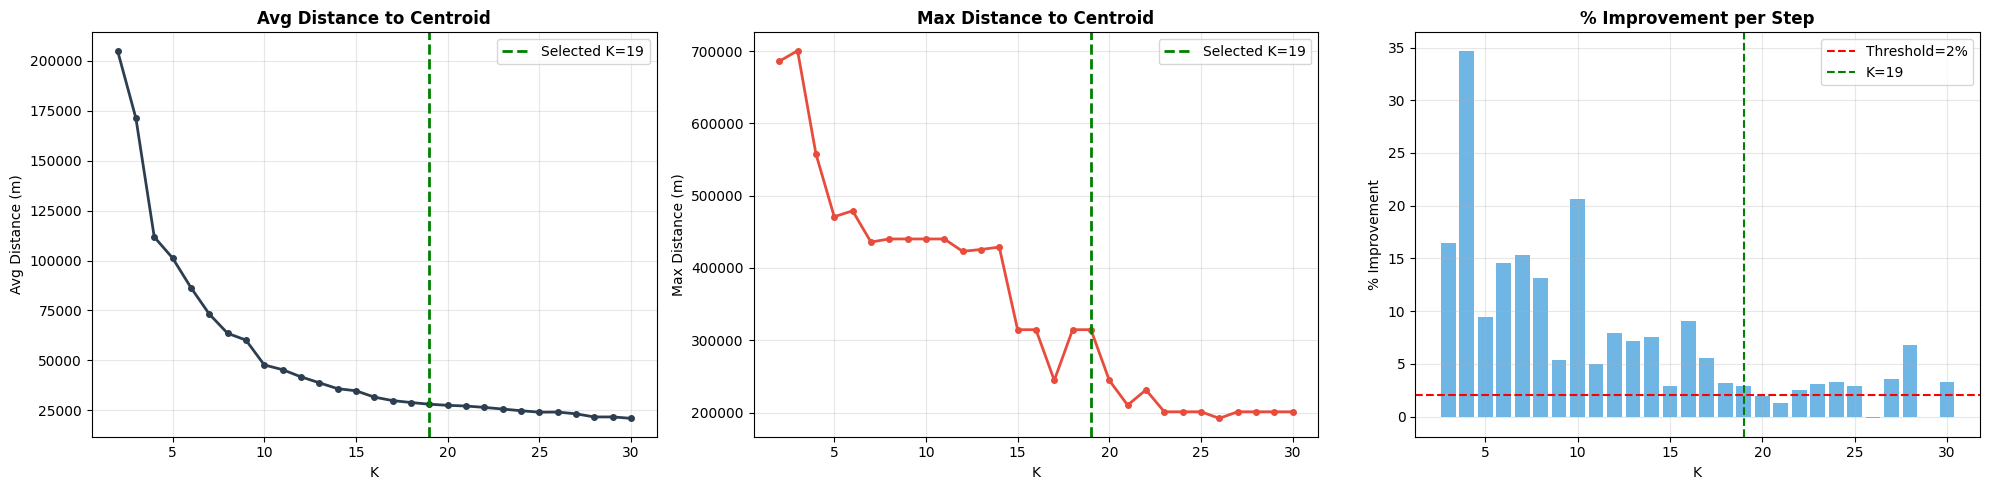

Saved: distance_analysis.png

Running final K-Means with K=19...
Clustering complete.
Converting X/Y to Lat/Lon (EPSG:5070 -> WGS84)...
Using existing Lat/Lon columns from data.
Conversion complete.
Calculating distance (miles) and drive time for each claim...



/tmp/ipykernel_963154/3643538761.py:196: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_colors)


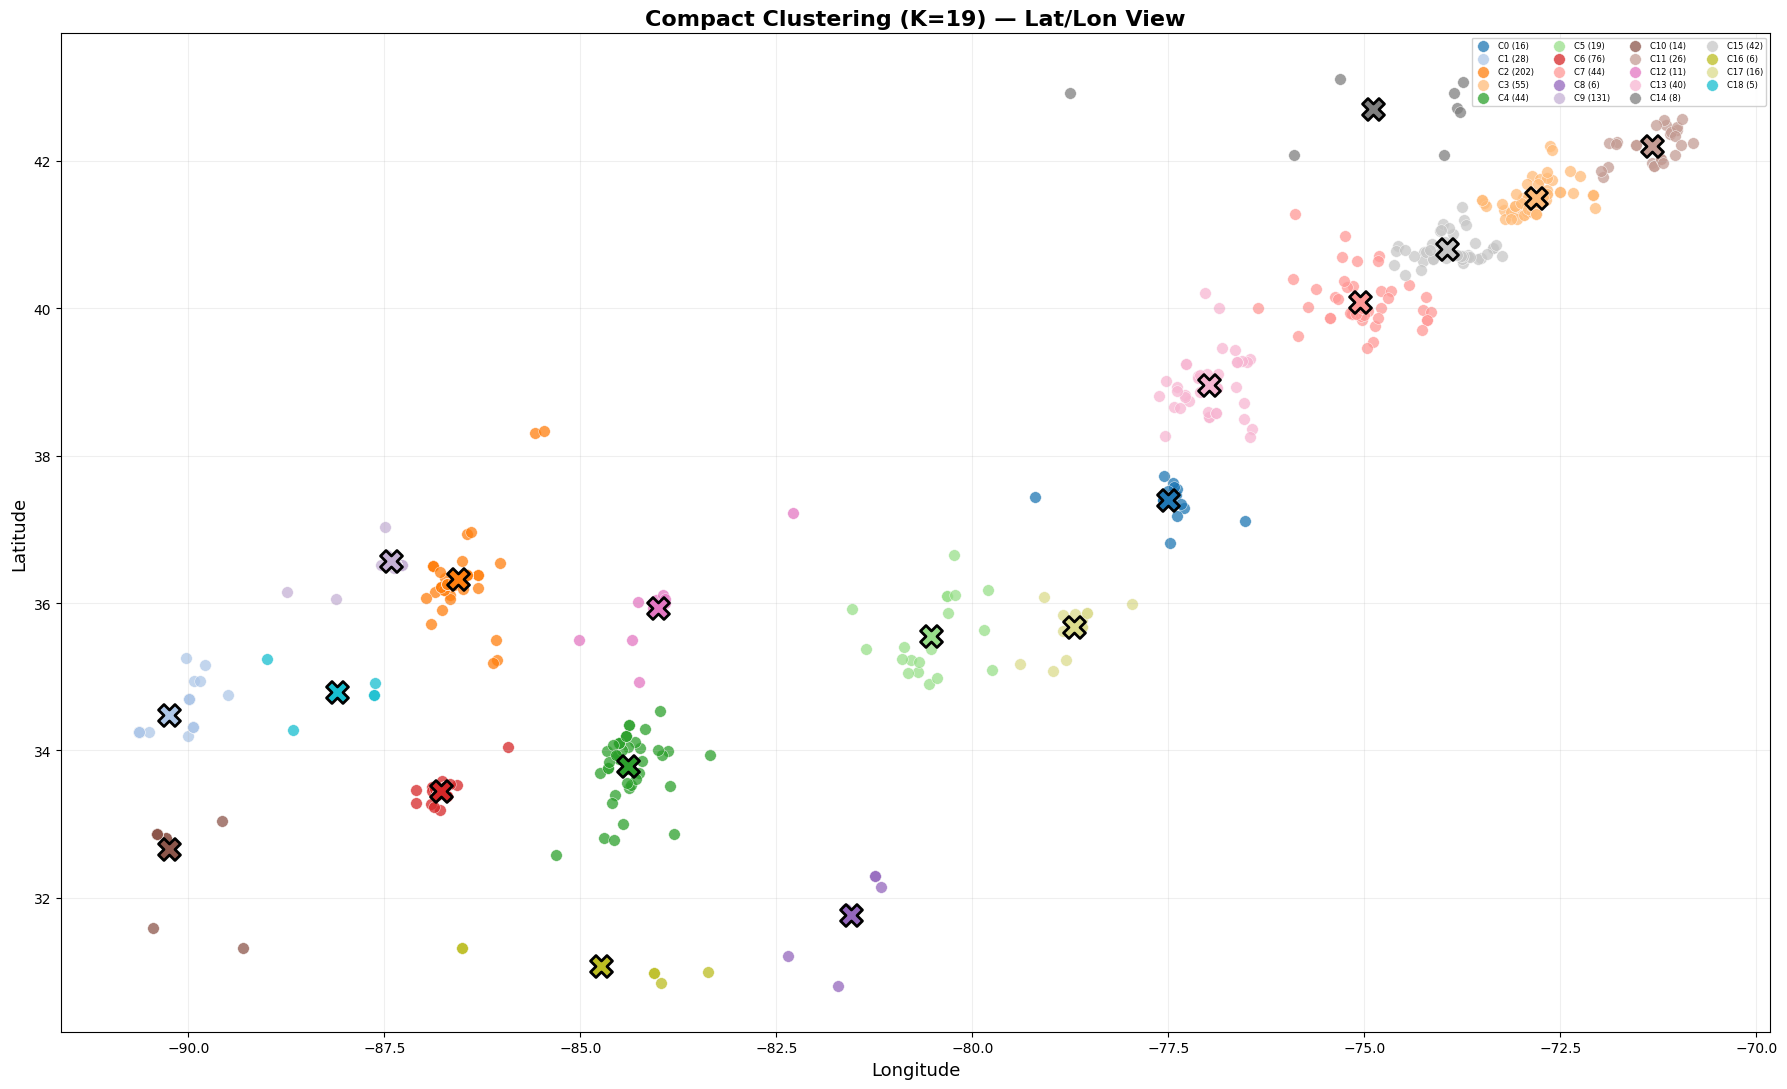

Saved: cluster_map_latlon.png

  COMPACT CLUSTERING RESULTS: K = 19
         Claims  Centroid_Lat  Centroid_Lon  Avg_Miles  Max_Miles  Avg_Drive_Min  Max_Drive_Min
Cluster                                                                                        
0            16         37.40        -77.50      20.52      93.66          35.57         162.34
1            28         34.47        -90.25      28.13      55.06          48.76          95.44
2           202         36.33        -86.56      10.58     151.14          18.35         261.97
3            55         41.50        -72.81      20.59      49.51          35.69          85.82
4            44         33.79        -84.39      28.92      99.70          50.14         172.81
5            19         35.55        -80.53      40.01      77.82          69.35         134.89
6            76         33.45        -86.78       5.26      64.08           9.12         111.07
7            44         40.09        -75.05      30.75      93.00   

In [4]:
"""
Claims Clustering — Compact Clusters + Lat/Lon + Time/Distance Matrix
======================================================================
1. Clusters claims on X, Y (EPSG:5070 NAD83 Conus Albers)
2. Converts X/Y and cluster centroids back to Lat/Lon
3. Calculates straight-line distance (miles) and estimated drive time
   from each claim to its cluster centroid

Requirements:
    pip install pandas scikit-learn openpyxl matplotlib pyproj
"""

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pyproj import Transformer
from math import radians, sin, cos, sqrt, atan2

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION                                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

INPUT_FILE = "Datasets/ds_claim_optClean_projected.xlsx"
OUTPUT_FILE = "claims_clustered.xlsx"
SHEET_NAME = 0
X_COL = "X"
Y_COL = "Y"
MIN_K = 2
MAX_K = 30                # Reduced for speed (increase if needed)
IMPROVEMENT_THRESHOLD = 0.02  # Stop when avg distance improvement < 2%

# Projection: EPSG:5070 (NAD83 Conus Albers Equal Area Conic, meters)
PROJ_CRS = "EPSG:5070"
GEO_CRS  = "EPSG:4326"

# Drive time estimation
AVG_SPEED_MPH = 45

# ╔══════════════════════════════════════════════════════════════════╗
# ║  HELPER FUNCTIONS                                              ║
# ╚══════════════════════════════════════════════════════════════════╝

proj_to_geo = Transformer.from_crs(PROJ_CRS, GEO_CRS, always_xy=True)

def xy_to_latlon(x, y):
    lon, lat = proj_to_geo.transform(x, y)
    return lat, lon

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 1: Read Data                                             ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Reading data from:", INPUT_FILE)
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)
print(f"Loaded {len(df)} records with {len(df.columns)} columns")
print(f"Columns found: {list(df.columns)}\n")

if X_COL not in df.columns or Y_COL not in df.columns:
    raise ValueError(f"Columns '{X_COL}' and/or '{Y_COL}' not found.\nAvailable: {list(df.columns)}")

before = len(df)
df = df.dropna(subset=[X_COL, Y_COL])
if len(df) < before:
    print(f"Dropped {before - len(df)} rows with missing X/Y values")

coords = df[[X_COL, Y_COL]].values

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 2: Evaluate K for Compactness (with progress)           ║
# ╚══════════════════════════════════════════════════════════════════╝

print(f"Evaluating K={MIN_K} to K={MAX_K} for maximum compactness...")
print(f"Stopping when improvement < {IMPROVEMENT_THRESHOLD*100:.0f}% per step\n")

K_range = list(range(MIN_K, MAX_K + 1))
avg_distances = []
max_distances = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(coords)
    dists = np.sqrt(np.sum((coords - km.cluster_centers_[labels]) ** 2, axis=1))
    avg_distances.append(np.mean(dists))
    max_distances.append(np.max(dists))
    print(f"  K={k:>2d}  AvgDist={np.mean(dists):>12,.2f}  MaxDist={np.max(dists):>12,.2f}")

# Select K: keep going until % improvement drops below threshold
best_k = K_range[0]
for i in range(1, len(K_range)):
    pct_improvement = (avg_distances[i-1] - avg_distances[i]) / avg_distances[i-1]
    if pct_improvement < IMPROVEMENT_THRESHOLD:
        best_k = K_range[i-1]
        break
else:
    best_k = K_range[-1]

best_idx = K_range.index(best_k)
print(f"\n>>> Selected K = {best_k}")
print(f"    Avg distance to centroid: {avg_distances[best_idx]:,.2f} meters")
print(f"    Max distance to centroid: {max_distances[best_idx]:,.2f} meters")
print(f"    Avg claims per cluster:   {len(df) / best_k:.1f}\n")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 3: Distance Analysis Plots                              ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(K_range, avg_distances, "o-", color="#2c3e50", linewidth=2, markersize=4)
axes[0].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Avg Distance (m)")
axes[0].set_title("Avg Distance to Centroid", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, max_distances, "o-", color="#e74c3c", linewidth=2, markersize=4)
axes[1].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Max Distance (m)")
axes[1].set_title("Max Distance to Centroid", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

pct_imp = [(avg_distances[i-1]-avg_distances[i])/avg_distances[i-1]*100 for i in range(1,len(avg_distances))]
axes[2].bar(K_range[1:], pct_imp, color="#3498db", alpha=0.7)
axes[2].axhline(y=IMPROVEMENT_THRESHOLD*100, color="red", linestyle="--", label=f"Threshold={IMPROVEMENT_THRESHOLD*100:.0f}%")
axes[2].axvline(x=best_k, color="green", linestyle="--", label=f"K={best_k}")
axes[2].set_xlabel("K"); axes[2].set_ylabel("% Improvement")
axes[2].set_title("% Improvement per Step", fontweight="bold")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distance_analysis.png")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 4: Final Clustering                                     ║
# ╚══════════════════════════════════════════════════════════════════╝

print("\nRunning final K-Means with K={}...".format(best_k))
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(coords)
centroids = kmeans.cluster_centers_
print("Clustering complete.")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 5: Convert X/Y and Centroids to Lat/Lon                 ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Converting X/Y to Lat/Lon (EPSG:5070 -> WGS84)...")

centroid_latlon = np.array([xy_to_latlon(c[0], c[1]) for c in centroids])

df["Centroid_X"] = centroids[df["Cluster"].values, 0]
df["Centroid_Y"] = centroids[df["Cluster"].values, 1]
df["Centroid_Lat"] = centroid_latlon[df["Cluster"].values, 0]
df["Centroid_Lon"] = centroid_latlon[df["Cluster"].values, 1]

if "Lat" in df.columns and "Lon" in df.columns:
    print("Using existing Lat/Lon columns from data.")
    df["Claim_Lat"] = df["Lat"]
    df["Claim_Lon"] = df["Lon"]
else:
    print("Converting claim X/Y to Lat/Lon...")
    latlon = np.array([xy_to_latlon(r[X_COL], r[Y_COL]) for _, r in df.iterrows()])
    df["Claim_Lat"] = latlon[:, 0]
    df["Claim_Lon"] = latlon[:, 1]

print("Conversion complete.")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 6: Time-Distance Matrix (Each Point to Its Centroid)    ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Calculating distance (miles) and drive time for each claim...\n")

df["Straight_Line_Miles"] = df.apply(
    lambda r: haversine_miles(r["Claim_Lat"], r["Claim_Lon"], r["Centroid_Lat"], r["Centroid_Lon"]),
    axis=1
)
df["Est_Road_Miles"] = df["Straight_Line_Miles"] * 1.3
df["Est_Drive_Time_Min"] = df["Est_Road_Miles"] / AVG_SPEED_MPH * 60

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 7: Cluster Map (Lat/Lon)                                ║
# ╚══════════════════════════════════════════════════════════════════╝

n_colors = max(best_k, 20)
cmap = cm.get_cmap("tab20", n_colors)
fig, ax = plt.subplots(figsize=(18, 11))

for i in range(best_k):
    mask = df["Cluster"] == i
    cluster_df = df[mask]
    color = cmap(i % n_colors)
    ax.scatter(cluster_df["Claim_Lon"], cluster_df["Claim_Lat"],
               c=[color], s=70, alpha=0.75, edgecolors="white", linewidth=0.4,
               label=f"C{i} ({mask.sum()})")
    ax.scatter(centroid_latlon[i, 1], centroid_latlon[i, 0],
               c=[color], s=250, marker="X", edgecolors="black", linewidth=2, zorder=5)

ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title(f"Compact Clustering (K={best_k}) — Lat/Lon View", fontsize=16, fontweight="bold")
ax.legend(fontsize=6, loc="best", framealpha=0.9, ncol=4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("cluster_map_latlon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_map_latlon.png")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 8: Cluster Summary                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 100)
print(f"  COMPACT CLUSTERING RESULTS: K = {best_k}")
print("=" * 100)

summary = df.groupby("Cluster").agg(
    Claims=("Cluster", "count"),
    Centroid_Lat=("Centroid_Lat", "first"),
    Centroid_Lon=("Centroid_Lon", "first"),
    Avg_Miles=("Straight_Line_Miles", "mean"),
    Max_Miles=("Straight_Line_Miles", "max"),
    Avg_Drive_Min=("Est_Drive_Time_Min", "mean"),
    Max_Drive_Min=("Est_Drive_Time_Min", "max"),
).round(2)

print(summary.to_string())

print("\nCluster Centers (Lat/Lon):")
for i in range(best_k):
    n = (df["Cluster"] == i).sum()
    avg_mi = df.loc[df["Cluster"]==i, "Straight_Line_Miles"].mean()
    avg_t = df.loc[df["Cluster"]==i, "Est_Drive_Time_Min"].mean()
    print(f"  Cluster {i:>2d}: Lat={centroid_latlon[i,0]:>9.4f}  Lon={centroid_latlon[i,1]:>10.4f}  "
          f"Claims={n:>3d}  AvgDist={avg_mi:>6.1f} mi  AvgTime={avg_t:>5.1f} min")

# Additional detail
extra_aggs = {}
if "CAT Severity Code" in df.columns:
    extra_aggs["Avg_Severity"] = ("CAT Severity Code", "mean")
if "SLA Days" in df.columns:
    extra_aggs["Avg_SLA_Days"] = ("SLA Days", "mean")
if "On-Site Handling" in df.columns:
    extra_aggs["OnSite_Pct"] = ("On-Site Handling", "mean")
if "Division" in df.columns:
    extra_aggs["Divisions"] = ("Division", lambda x: ", ".join(sorted(x.unique())))

if extra_aggs:
    detail = df.groupby("Cluster").agg(**extra_aggs).round(2)
    if "OnSite_Pct" in detail.columns:
        detail["OnSite_Pct"] = (detail["OnSite_Pct"] * 100).round(1).astype(str) + "%"
    print("\nAdditional Detail:")
    print(detail.to_string())

print(f"\nOverall Avg Straight-Line Distance: {df['Straight_Line_Miles'].mean():.2f} miles")
print(f"Overall Max Straight-Line Distance: {df['Straight_Line_Miles'].max():.2f} miles")
print(f"Overall Avg Est Drive Time:         {df['Est_Drive_Time_Min'].mean():.1f} min")
print(f"Overall Max Est Drive Time:         {df['Est_Drive_Time_Min'].max():.1f} min")

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 9: Time-Distance Matrix Report                          ║
# ╚══════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 130)
print("  TIME-DISTANCE MATRIX: EACH CLAIM TO ITS CLUSTER CENTROID")
print("=" * 130)

matrix = df[["Claim Number", "Cluster",
             "Claim_Lat", "Claim_Lon",
             "Centroid_Lat", "Centroid_Lon",
             "Straight_Line_Miles", "Est_Road_Miles", "Est_Drive_Time_Min"]].copy()
matrix = matrix.sort_values(["Cluster", "Straight_Line_Miles"])
matrix["Straight_Line_Miles"] = matrix["Straight_Line_Miles"].round(2)
matrix["Est_Road_Miles"] = matrix["Est_Road_Miles"].round(2)
matrix["Est_Drive_Time_Min"] = matrix["Est_Drive_Time_Min"].round(1)
matrix["Claim_Lat"] = matrix["Claim_Lat"].round(4)
matrix["Claim_Lon"] = matrix["Claim_Lon"].round(4)
matrix["Centroid_Lat"] = matrix["Centroid_Lat"].round(4)
matrix["Centroid_Lon"] = matrix["Centroid_Lon"].round(4)

print(matrix.to_string(index=False))

# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 10: Export to Excel                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Clustered Claims", index=False)
    summary.to_excel(writer, sheet_name="Cluster Summary")
    matrix.to_excel(writer, sheet_name="Time-Distance Matrix", index=False)

print(f"\nResults exported to: {OUTPUT_FILE}")
print("  Sheet 1: Clustered Claims     (all data + cluster + distances)")
print("  Sheet 2: Cluster Summary      (per-cluster stats)")
print("  Sheet 3: Time-Distance Matrix (each claim vs centroid)")
print("\nDone!")

In [5]:
df.loc[df["Straight_Line_Miles"].idxmax(), ["Claim Number", "Cluster", "Straight_Line_Miles"]]

Claim Number           9.632686e+07
Cluster                1.400000e+01
Straight_Line_Miles    1.961042e+02
Name: 423, dtype: float64